In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


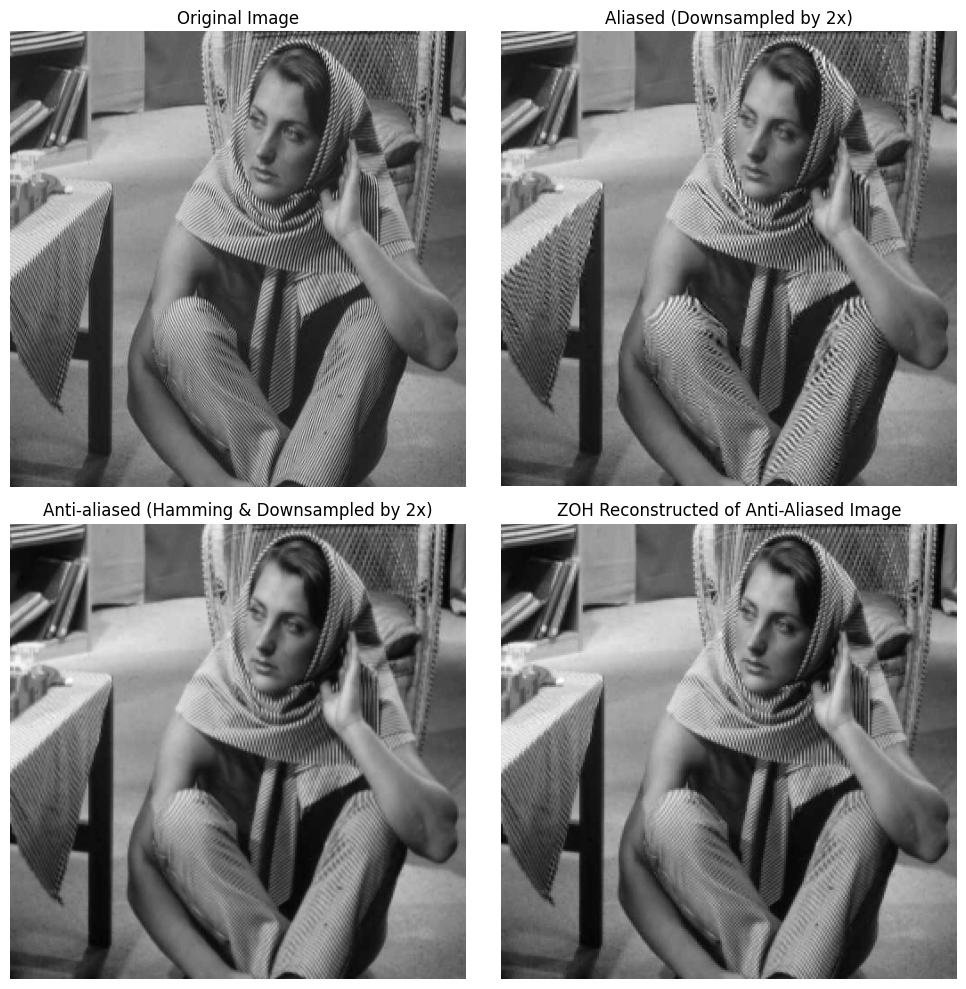

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image
from PIL import Image
import scipy.io as sio
from scipy.ndimage import zoom

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'
# Load an image (replace 'your_image.jpg' with a path to your image)
try:
    img = sio.loadmat(work_path + 'Data/barb.mat')['barb']
except FileNotFoundError:
    print("Error: 'barb.mat' not found. Please provide a valid image path.")
    # Create a simple image for demonstration if no image is found
    size = 200
    img_array = np.zeros((size, size), dtype=np.uint8)
    for i in range(size):
        for j in range(size):
            if (i // 10 + j // 10) % 2 == 0:
                img_array[i, j] = 255
    img = Image.fromarray(img_array)
    print("Using a generated checkerboard pattern image instead.")


original_size = img.shape # Get image shape (height, width, channels)
downsample_factor = 2 # Downsample by a factor of 4 (e.g., 400x400 to 100x100)

# Calculate new dimensions
new_height = original_size[0] // downsample_factor # Access height
new_width = original_size[1] // downsample_factor # Access width


# 1. Downsampling without anti-aliasing (aliasing will occur)
# Need to convert the image to a PIL Image first to use resize
img_pil = Image.fromarray(img)
img_aliased = img_pil.resize((new_width, new_height), Image.NEAREST)

# 2. Downsampling with anti-aliasing (using a high-quality filter like BICUBIC)
# Alternatively, apply a Gaussian blur *before* resizing for explicit anti-aliasing
# For simplicity, we'll use PIL's built-in anti-aliasing during resize
img_antialiased = img_pil.resize((new_width, new_height), Image.HAMMING)

zp_antialiased_reconstructed = zoom(img_antialiased, downsample_factor, order=0)
zp_antialiased_reconstructed = zp_antialiased_reconstructed[:original_size[0], :original_size[1]]

# Display the results
#fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
ax = axes.ravel()

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(img_aliased, cmap='gray')
ax[1].set_title(f'Aliased (Downsampled by {downsample_factor}x)')
ax[1].axis('off')

ax[2].imshow(img_antialiased, cmap='gray')
ax[2].set_title(f'Anti-aliased (Hamming & Downsampled by {downsample_factor}x)')
ax[2].axis('off')

ax[3].imshow(zp_antialiased_reconstructed, cmap='gray')
ax[3].set_title(f'ZOH Reconstructed of Anti-Aliased Image')
ax[3].axis('off')

plt.tight_layout()
plt.show()